<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/05_model_comparison_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Model Comparison & Production Pipeline
### Master Notebook — run this last

Pulls together the exported metrics/models from Notebooks 02, 03, and 04, builds the comparison table + side-by-side visualizations, profiles the winning segments into human-readable personas, and assembles the final deployable pipeline (`model.joblib`) that the Gradio app (VS Code side) loads.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
RANDOM_STATE = 42
PROJECT_ROOT = '/content/drive/MyDrive/customer-segmentation-ml'


Mounted at /content/drive


## 1. Load everything Notebooks 01–04 produced

In [2]:
with open(f'{PROJECT_ROOT}/metrics/kmeans_results.json') as f:
    kmeans_results = json.load(f)
with open(f'{PROJECT_ROOT}/metrics/hierarchical_results.json') as f:
    hierarchical_results = json.load(f)
with open(f'{PROJECT_ROOT}/metrics/dbscan_results.json') as f:
    dbscan_results = json.load(f)

kmeans_model = joblib.load(f'{PROJECT_ROOT}/models/kmeans_model.pkl')
hierarchical_model = joblib.load(f'{PROJECT_ROOT}/models/hierarchical_model.pkl')
dbscan_model = joblib.load(f'{PROJECT_ROOT}/models/dbscan_model.pkl')

preprocessor = joblib.load(f'{PROJECT_ROOT}/models/preprocessor.joblib')
feature_cols = joblib.load(f'{PROJECT_ROOT}/models/preprocessor_input_columns.joblib')

X_df = pd.read_csv(f'{PROJECT_ROOT}/data/preprocessed_rfm_scaled.csv')
raw_df = pd.read_csv(f'{PROJECT_ROOT}/data/customer_features_raw.csv')
X = X_df.drop(columns=['Customer ID']).values

print('Loaded all artifacts.')

Loaded all artifacts.


## 2. Comparison table

Best params + metrics from each algorithm's own grid search. **Caveat, stated explicitly:** Hierarchical's metrics were computed on a 3,000-customer sample (see Notebook 03's note on `O(n²)` scaling), while KMeans and DBSCAN were evaluated on the full ~49,661 customers — so treat the Hierarchical row as directionally comparable, not exactly apples-to-apples.

In [3]:
comparison_rows = []
for name, res in [('KMeans', kmeans_results), ('Hierarchical', hierarchical_results), ('DBSCAN', dbscan_results)]:
    comparison_rows.append({
        'Algorithm': name,
        'Best params': json.dumps(res['best_params']),
        'Silhouette': round(res['best_metrics']['silhouette'], 3),
        'Davies-Bouldin': round(res['best_metrics']['davies_bouldin'], 3),
        'Calinski-Harabasz': round(res['best_metrics']['calinski_harabasz'], 1),
        '# clusters found': res['n_clusters_found'],
        'Native .predict()': 'Yes' if name == 'KMeans' else 'No',
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Algorithm,Best params,Silhouette,Davies-Bouldin,Calinski-Harabasz,# clusters found,Native .predict()
0,KMeans,"{""k"": 2, ""init"": ""random"", ""n_init"": 10}",0.201,2.131,9613.4,2,Yes
1,Hierarchical,"{""k"": 2, ""linkage"": ""average"", ""metric"": ""eucl...",0.494,0.896,54.7,2,No
2,DBSCAN,"{""eps"": 0.5, ""min_samples"": 5}",0.530,0.643,125.6,91,No


In [4]:
comparison_df.to_csv(f'{PROJECT_ROOT}/metrics/comparison_table.csv', index=False)
print(comparison_df.to_markdown(index=False))


| Algorithm    | Best params                                           |   Silhouette |   Davies-Bouldin |   Calinski-Harabasz |   # clusters found | Native .predict()   |
|:-------------|:------------------------------------------------------|-------------:|-----------------:|--------------------:|-------------------:|:--------------------|
| KMeans       | {"k": 2, "init": "random", "n_init": 10}              |        0.201 |            2.131 |              9613.4 |                  2 | Yes                 |
| Hierarchical | {"k": 2, "linkage": "average", "metric": "euclidean"} |        0.494 |            0.896 |                54.7 |                  2 | No                  |
| DBSCAN       | {"eps": 0.5, "min_samples": 5}                        |        0.53  |            0.643 |               125.6 |                 91 | No                  |


## 3. Side-by-side PCA visualization

One PCA projection fit on the full dataset, reused for all three panels so they're visually comparable (Hierarchical's panel plots only its 3,000-customer sample, projected through the same PCA).

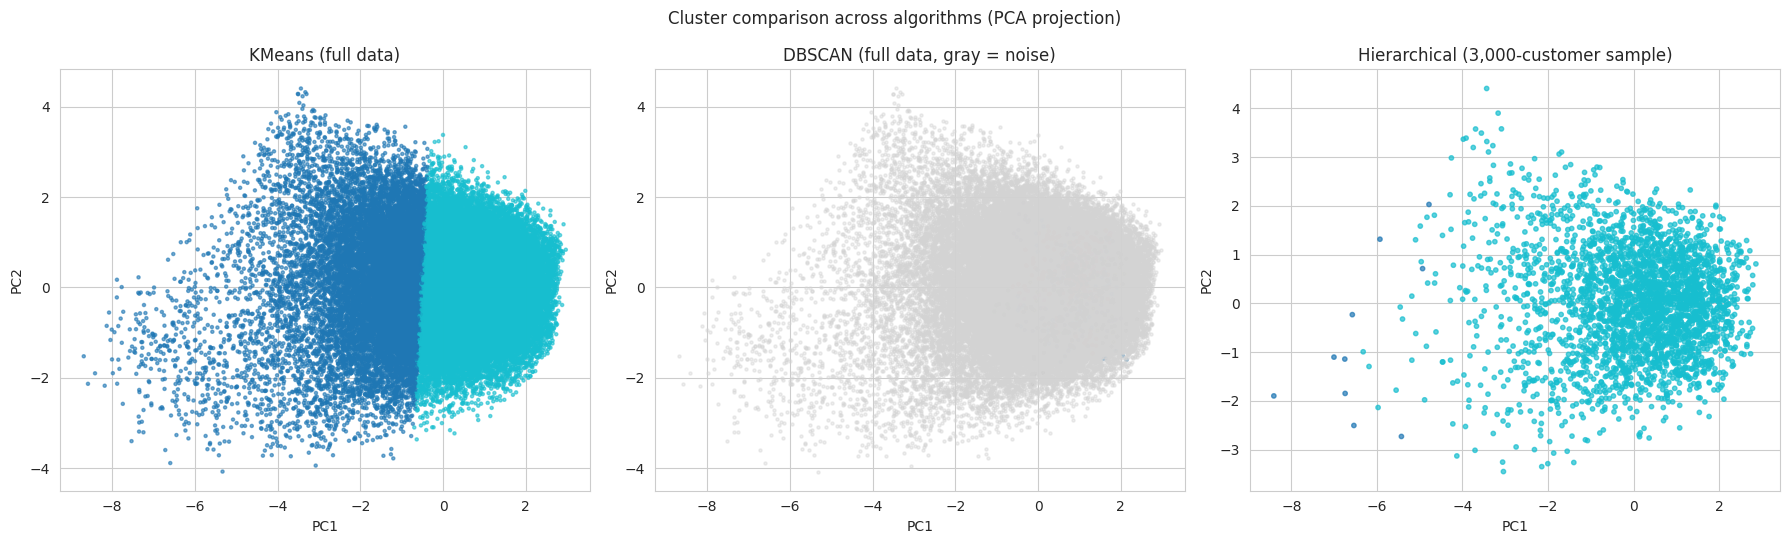

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X)

kmeans_labels = kmeans_model.predict(X)
dbscan_labels = dbscan_model.labels_  # DBSCAN has no .predict(); reuse the labels_ from its original fit

# recreate the exact same sample Notebook 03 used, to align with hierarchical_model's fitted labels
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X), size=3000, replace=False)
hier_labels = hierarchical_model.labels_
X_pca_sample = X_pca_full[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=kmeans_labels, cmap='tab10', s=5, alpha=0.6)
axes[0].set_title('KMeans (full data)')

is_noise = dbscan_labels == -1
axes[1].scatter(X_pca_full[~is_noise, 0], X_pca_full[~is_noise, 1], c=dbscan_labels[~is_noise], cmap='tab10', s=5, alpha=0.6)
axes[1].scatter(X_pca_full[is_noise, 0], X_pca_full[is_noise, 1], c='lightgray', s=5, alpha=0.4)
axes[1].set_title('DBSCAN (full data, gray = noise)')

axes[2].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=hier_labels, cmap='tab10', s=10, alpha=0.7)
axes[2].set_title('Hierarchical (3,000-customer sample)')

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Cluster comparison across algorithms (PCA projection)')
plt.tight_layout()
plt.show()


## 4. Which model gets deployed?

Only **KMeans** has a native `.predict()` that works on a brand-new customer it wasn't fit on — DBSCAN and Agglomerative only assign labels to the data they were originally fit on. Per the guide, we deploy KMeans as the production pipeline and present DBSCAN/Hierarchical as comparison analysis. (If you'd rather deploy a KNN-on-top-of-DBSCAN-labels approach instead, that's the guide's documented alternative — not implemented here since KMeans is the recommended, simpler path.)

In [6]:
print('Deploying KMeans:')
print(json.dumps(kmeans_results['best_params'], indent=2))
print(json.dumps(kmeans_results['best_metrics'], indent=2))


Deploying KMeans:
{
  "k": 2,
  "init": "random",
  "n_init": 10
}
{
  "silhouette": 0.20083343542449608,
  "davies_bouldin": 2.131279993910449,
  "calinski_harabasz": 9613.417785995594
}


## 5. Persona profiling

Cluster averages in **real units** (dollars, days, order counts) — we use the unscaled `customer_features_raw.csv` table joined to the KMeans labels, so there's no need to manually invert the scaler/log transform.

In [7]:
persona_df = raw_df.copy()
persona_df['cluster'] = kmeans_labels

persona_cols = ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'avg_quantity', 'return_rate', 'churn']
persona_table = persona_df.groupby('cluster')[persona_cols].mean().round(2)
persona_table['n_customers'] = persona_df.groupby('cluster').size()
persona_table['pct_of_base'] = (persona_table['n_customers'] / len(persona_df) * 100).round(1)
persona_table


,recency_days,frequency,monetary_total,monetary_avg,avg_quantity,return_rate,churn,n_customers,pct_of_base
cluster,,,,,,,,,
0,456.45,2.86,6608.46,2422.58,2.99,40.47,0.2,14963,30.1
1,178.63,5.95,16724.80,2858.50,3.01,40.67,0.2,34698,69.9


## 6. Behavioral heatmap

Z-scored cluster averages (relative to the overall customer base) — makes it easy to see, per cluster, which features are unusually high or low.

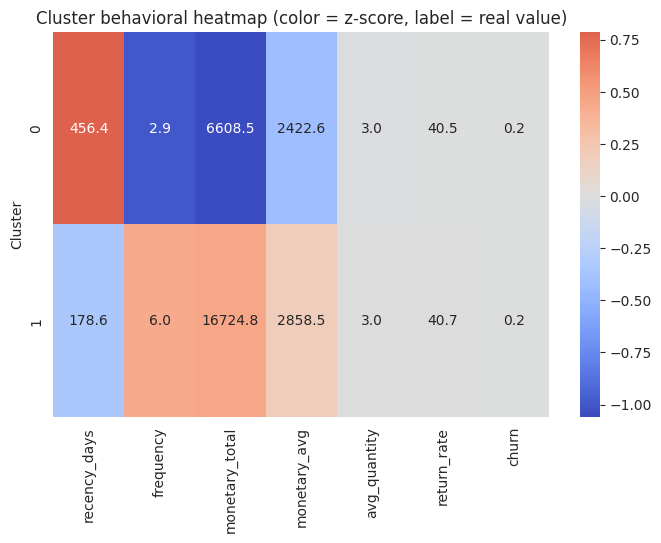

In [8]:
zscored = (persona_table[persona_cols] - persona_df[persona_cols].mean()) / persona_df[persona_cols].std()

plt.figure(figsize=(8, 5))
sns.heatmap(zscored, annot=persona_table[persona_cols].values, fmt='.1f', cmap='coolwarm', center=0)
plt.title('Cluster behavioral heatmap (color = z-score, label = real value)')
plt.ylabel('Cluster')
plt.show()


## 7. Assign human-readable persona labels

Inspect the table/heatmap above, then fill in a name for each cluster ID below (the number of clusters and which ID means what is data-dependent, so this is a manual step — same as the guide's `CLUSTER_LABELS` dict in the Gradio app).

In [9]:
CLUSTER_LABELS = {
    # cluster_id: 'persona name',
    # e.g. 0: 'High-value loyal customer',
    #      1: 'Occasional bargain shopper',
    #      2: 'At-risk / churn-prone',
}
# fall back to a generic name for any cluster not manually labeled yet
for cid in sorted(persona_df['cluster'].unique()):
    CLUSTER_LABELS.setdefault(int(cid), f'Segment {cid} (label pending review)')

CLUSTER_LABELS


{0: 'Segment 0 (label pending review)', 1: 'Segment 1 (label pending review)'}

## 8. Build & export the final production pipeline

Combines the fitted `preprocessor` (log-transform + scaling + encoding, from Notebook 01) with the fitted `kmeans_model` (from Notebook 02) into one end-to-end `Pipeline`. This is what the Gradio app loads — it takes a **raw** customer-level row (recency, frequency, monetary totals, etc. — not scaled, not log-transformed) and returns a cluster ID directly.

In [10]:
final_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', kmeans_model),
])

joblib.dump(final_pipeline, f'{PROJECT_ROOT}/models/model.joblib')
joblib.dump(final_pipeline, f'{PROJECT_ROOT}/models/final_unified_pipeline.pkl')  # same object, docx-style filename
joblib.dump(CLUSTER_LABELS, f'{PROJECT_ROOT}/models/cluster_labels.joblib')

print('Saved models/model.joblib (load this in the Gradio app)')


Saved models/model.joblib (load this in the Gradio app)


## 9. Teacher / evaluator 1-click inference test

Self-contained sanity check: load the exported pipeline fresh and score one made-up customer.

In [11]:
# =====================================================================
# TEACHER / EVALUATOR 1-CLICK INFERENCE TEST
# =====================================================================
import joblib
import pandas as pd

loaded_pipeline = joblib.load(f'{PROJECT_ROOT}/models/model.joblib')
loaded_labels = joblib.load(f'{PROJECT_ROOT}/models/cluster_labels.joblib')

# Mock a customer-level input row (this is what the Gradio form collects)
mock_customer = pd.DataFrame([{
    'recency_days': 4,
    'frequency': 22,
    'monetary_total': 3200.0,
    'monetary_avg': 145.5,
    'avg_quantity': 3.1,
    'return_rate': 5.0,
    'age': 34,
    'gender': 'Female',
    'favorite_category': 'Electronics',
    'favorite_payment': 'Credit Card',
}])

cluster_id = loaded_pipeline.predict(mock_customer)[0]
print(f'Predicted Cluster ID : {cluster_id}')
print(f'Assigned Persona     : {loaded_labels.get(cluster_id, "General Customer")}')


Predicted Cluster ID : 0
Assigned Persona     : Segment 0 (label pending review)


## Done

`models/model.joblib` is ready — download it (or leave it in Drive and download from there) and drop it into the VS Code `customer-segmentation-app/` project as described in the guide, alongside `app.py`.

In [12]:
from google.colab import files
files.download(f'{PROJECT_ROOT}/models/model.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>